<h2> Final Report Code </h2>
<h4> Sam Charpentier </h4>
5/8/26

Please add your filepath to Astragalus.csv in Phase 1 below. 

PHASE 1: DATA PREPARATION & AGGREGATION

Loaded 1317 inventories across 638 accessions
Columns: ['Accession', 'Suffix', 'Inventory', 'Year', 'SeedAge', 'Viability', 'ViabilityDate', 'ViabilityYear', 'AgeAtTest', 'YearsSinceTest', 'Status', 'Species', 'Origin', 'Type', 'SeedExists', 'Backup', 'Distributable', 'Available', '100SeedWeight', 'EstTotalSeed', 'EstLiveSeed']

After removing rows with invalid SeedAge: 1309 inventories remain
  Marked 16 invalid/inherited viability tests as invalid
  Valid viability tests remaining: 532
After removing rows with invalid Status: 1038 inventories remain
After setting invalid SeedAge to 200: 1038 inventories remain

PHASE 2: VIABILITY DETERIORATION MODEL

STEP 2.1: Fitting global viability deterioration model...
  Sample size for model: 532 accessions with valid viability tests and AgeAtTest

Global Linear Model Results:
  Intercept: 91.71%
  Slope: -0.8507%/year
  R-squared: 0.3121
  p-value (AgeAtTest): 5.5075e-45


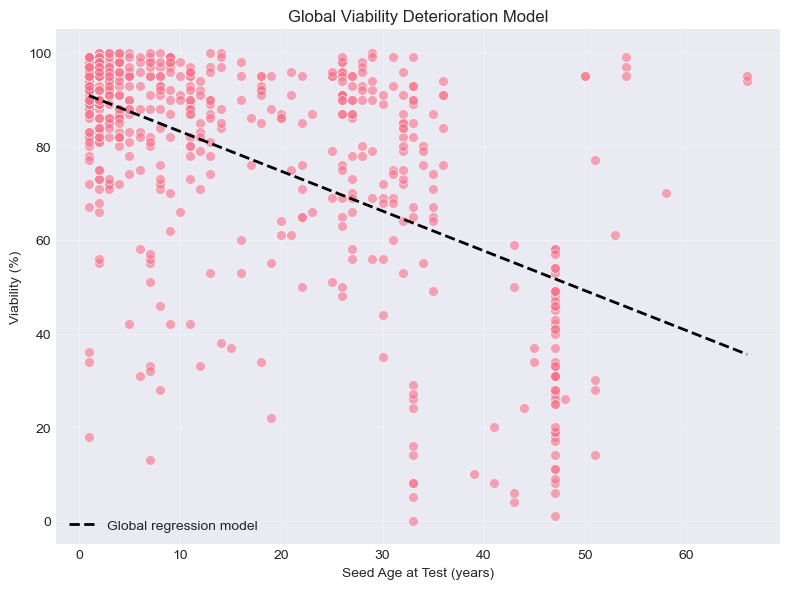


STEP 2.2: Predicting current (2026) viability for all accessions...
  Current (2026) viability estimated for all 532 accessions
  Mean estimated viability: 59.1%
  Median estimated viability: 64.7%

Deterioration trajectory:
  Years to drop from 50% to 10% viability: 47.0 years

STEP 2.3: Testing for significant group effects...
RESEARCH QUESTION: Does adding Species or Origin explain significantly more variation in viability deterioration than age alone?

ANOVA: Does Species significantly affect deterioration?
  F-statistic: 2.8724
  p-value: 4.6678e-14
  SIGNIFICANT: True

ANOVA: Does Origin significantly affect deterioration?
  F-statistic: 2.1134
  p-value: 1.4380e-07
  SIGNIFICANT: True

STEP 2.4: Visualizing deterioration patterns by Species and Origin...
  Saved: 02_deterioration_by_group.png


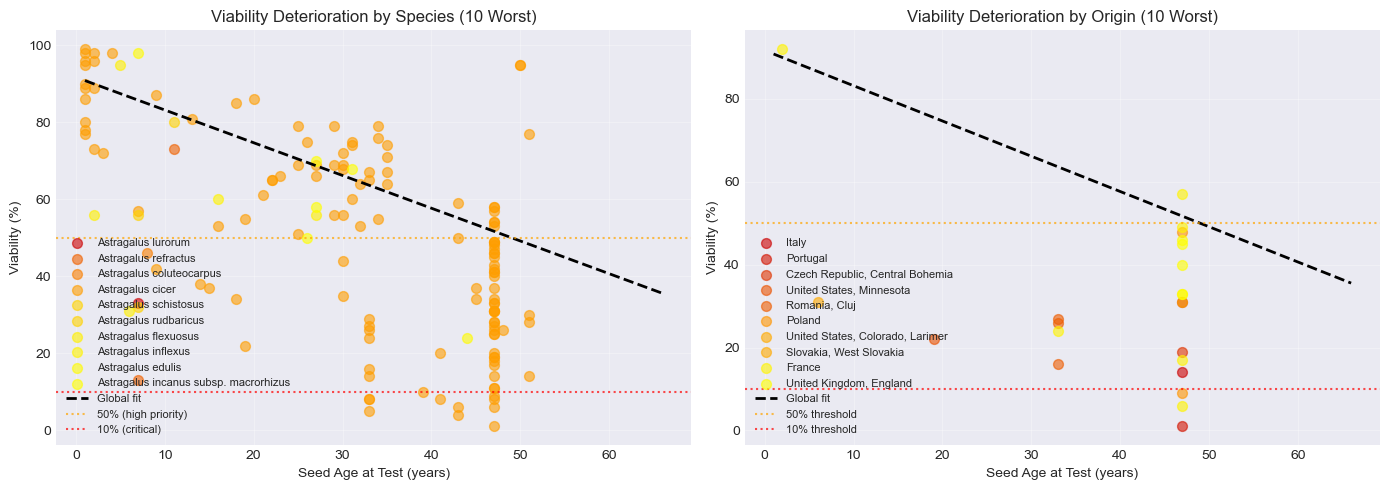


STEP 2.5: Identifying fastest-deteriorating species and origins...
Top 10 fastest-deteriorating species:
                                 Species      Slope  N_tests
50  Astragalus canadensis var. brevidens -12.500000        3
39               Astragalus platysematus -11.250000        2
35                  Astragalus alopecias  -7.265403        4
44                 Astragalus uliginosus  -2.666667        2
47               Astragalus melilotoides  -2.077586        5
49                  Astragalus davuricus  -2.000000        2
18                     Astragalus edulis  -2.000000        2
30               Astragalus nuttallianus  -1.411765        2
7                       Astragalus cicer  -1.063176      131
19                   Astragalus falcatus  -0.790108       38

Top 10 fastest-deteriorating origins:
                                Origin      Slope  N_tests
51               United States, Nevada -20.000000        2
49  United States, Colorado, Jefferson  -7.000000        2
46     

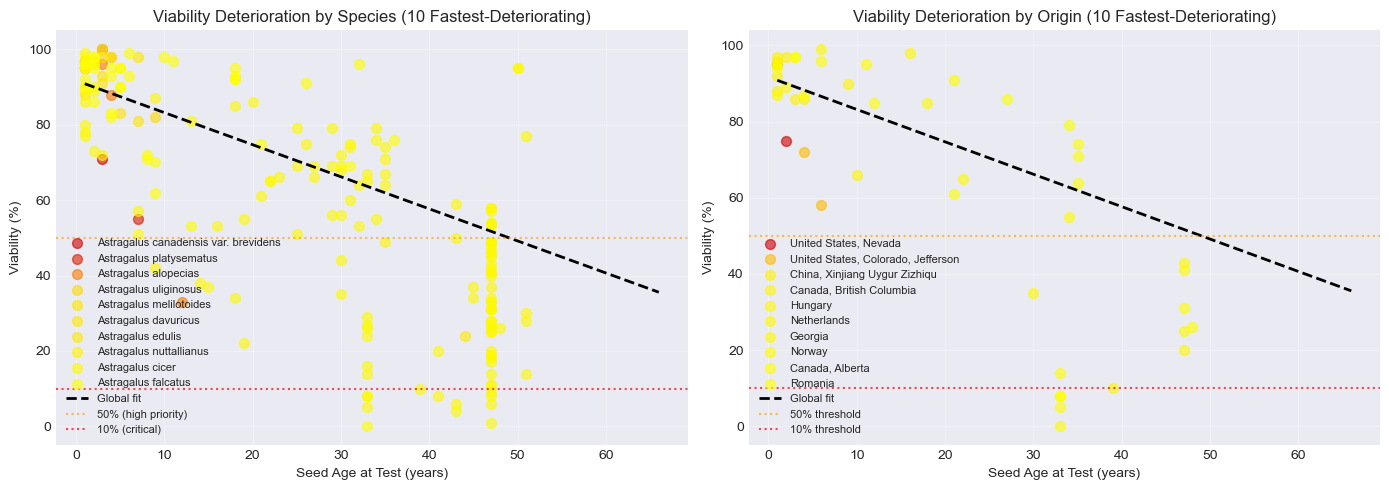


STEP 2.6: Predicting current viability for ranking dataset...

Predictions complete for 618 accessions

Model usage summary:
ModelUsed
Species    483
Origin     111
Global      24
Name: count, dtype: int64

Predicted viability summary:
count    618.000000
mean      71.699661
std       21.601814
min        0.000000
25%       59.165183
50%       77.800773
75%       87.141827
max      100.000000
Name: PredictedViability_2026, dtype: float64

Generating ranking viability prediction plot...
  Saved: 04_predicted_viability_ranking.png


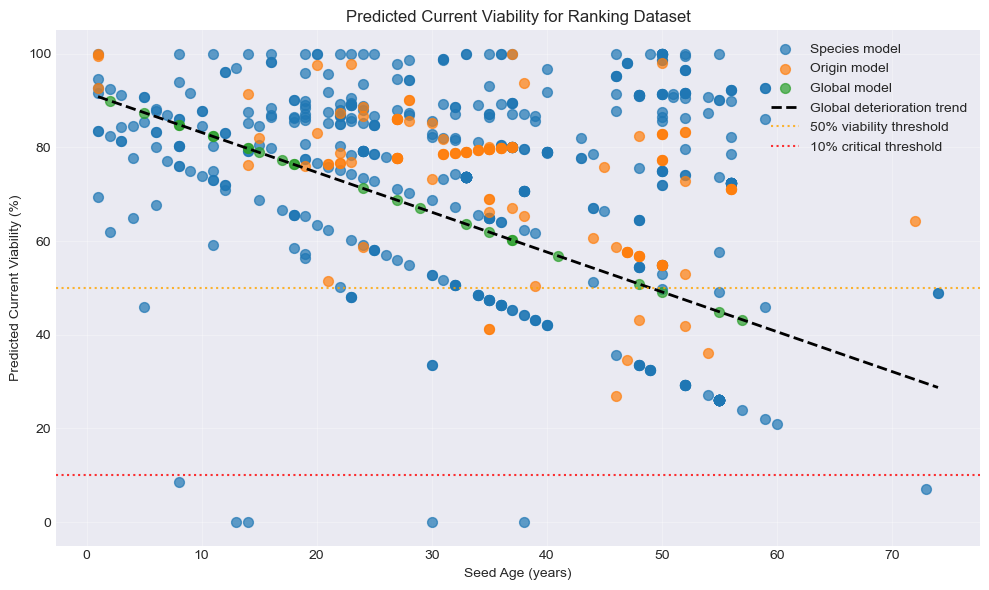


STEP 2.7: TOP 50 LOWEST-VIABILITY ACCESSIONS

Top 50 regeneration-priority accessions:

Accession                              Species                          Origin  SeedAge                                          PrimaryReason  EstimatedViability_2026  YearsRemainingTo0% ModelUsed
 W6 45649 Astragalus canadensis var. brevidens           United States, Nevada     13.0         Fast species deterioration; Critical viability                      0.0                 0.0   Species
 W6 43688 Astragalus canadensis var. brevidens             United States, Utah     14.0         Fast species deterioration; Critical viability                      0.0                 0.0   Species
PI 440154                 Astragalus alopecias                      Kazakhstan     38.0         Fast species deterioration; Critical viability                      0.0                 0.0   Species
PI 440156                 Astragalus alopecias                      Kazakhstan     30.0         Fast species deteriorat

In [2]:
"""
ASTRAGALUS SEEDBANK REGENERATION PRIORITY RANKING
Phase 1-4: Data preparation → Deterioration analysis → Composite scoring → Visualization
"""

# Import the things
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import warnings
warnings.filterwarnings('ignore')

# Set plotting defaults
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# PHASE 1: DATA PREPARATION & AGGREGATION
# ============================================================================

print("="*80)
print("PHASE 1: DATA PREPARATION & AGGREGATION")
print("="*80)

# Load data
#df = pd.read_csv(r"C:\Users\schar\Downloads\Astragalus.csv") #home
df = pd.read_csv(r"C:\Users\sam.charpentier\Downloads\Astragalus.csv") #office
#df = pd.read_csv(r"[Add your filepath here]) #instructor

# Confirm data loaded
print(f"\nLoaded {len(df)} inventories across {df['Accession'].nunique()} accessions")
print(f"Columns: {df.columns.tolist()}\n")

# Handle #VALUE! errors in SeedAge and AgeAtTest columns
df['SeedAge'] = pd.to_numeric(df['SeedAge'], errors='coerce')
df['AgeAtTest'] = pd.to_numeric(df['AgeAtTest'], errors='coerce')

# Remove rows with missing SeedAge (required for all analysis)
df = df.dropna(subset=['SeedAge']).reset_index(drop=True)
print(f"After removing rows with invalid SeedAge: {len(df)} inventories remain")

# For Modeling, create new dataframe with only positive AgeAtTest values and valid viability data
before_filter = df[df['Viability'].notna()].shape[0]
df_model = df[(df['AgeAtTest'] > 0) & (df['Viability'].notna())].copy()
after_filter = df_model.shape[0]
print(f"  Marked {before_filter - after_filter} invalid/inherited viability tests as invalid")
print(f"  Valid viability tests remaining: {after_filter}")

# For Ranking, keep only rows with valid Status (seed remaining)
valid_statuses = ["Available", "Original lot received", "Low inventory", "Low viability", "Packaged", "Quantity low, but inventory onhand above iv.dcritical","Replaced older sample with newer sample"]
df_exists = df[df['Status'].isin(valid_statuses)].copy()
print(f"After removing rows with invalid Status: {len(df_exists)} inventories remain")

# For Ranking, invalid SeedAge (such as 'uni' original seed) is set to 200
df_exists['SeedAge'].fillna(200, inplace=True)
print(f"After setting invalid SeedAge to 200: {len(df_exists)} inventories remain")

# For Ranking, choose the inventory with lowest SeedAge to assess the health of the entire accession 
df_ranking = df_exists.loc[df_exists.groupby('Accession')['SeedAge'].idxmin()].reset_index(drop=True)


# ============================================================================
# PHASE 2: VIABILITY DETERIORATION MODEL
# ============================================================================

print("\n" + "="*80)
print("PHASE 2: VIABILITY DETERIORATION MODEL")
print("="*80)

# STEP 2.1: Fit global linear deterioration model 
# ============================================================================
print("\nSTEP 2.1: Fitting global viability deterioration model...")
df_deterioration = df_model
print(f"  Sample size for model: {len(df_deterioration)} accessions with valid viability tests and AgeAtTest")

# Fit global linear model using AgeAtTest (not SeedAge!)
model_global = ols('Viability ~ AgeAtTest', data=df_deterioration).fit()
print("\nGlobal Linear Model Results:")
print(f"  Intercept: {model_global.params['Intercept']:.2f}%")
print(f"  Slope: {model_global.params['AgeAtTest']:.4f}%/year")
print(f"  R-squared: {model_global.rsquared:.4f}")
print(f"  p-value (AgeAtTest): {model_global.pvalues['AgeAtTest']:.4e}")

# Store model for later use
global_intercept = model_global.params['Intercept']
global_slope = model_global.params['AgeAtTest']

# Scatterplot with global regression line
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_deterioration,
    x='AgeAtTest',
    y='Viability',
    alpha=0.6,
    s=50)

# Regression line from fitted global model
age_range = np.linspace(
    df_deterioration['AgeAtTest'].min(),
    df_deterioration['AgeAtTest'].max(),
    100)
predicted_viability = global_intercept + (global_slope * age_range)
plt.plot(
    age_range,
    predicted_viability,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Global regression model')
plt.xlabel('Seed Age at Test (years)')
plt.ylabel('Viability (%)')
plt.title('Global Viability Deterioration Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sanity check
if global_slope > 0:
    print("\nWARNING: Positive slope detected! Check data for outliers or contamination.")

    
# STEP 2.2: Predict current (2026) viability for all accessions
# ============================================================================
print("\nSTEP 2.2: Predicting current (2026) viability for all accessions...")

def predict_current_viability(row, intercept, slope):
    """
    Estimate current viability in 2026 based on deterioration model.
    If viability test exists: extrapolate from test to 2026.
    If no test exists: estimate using global model and current SeedAge.
    """
    if pd.notna(row['Viability']) and pd.notna(row['ViabilityYear']):
        # Extrapolate from last test
        years_since_test = 2026 - row['ViabilityYear']
        estimated_viability = row['Viability'] + (slope * years_since_test)
    else:
        # No test; estimate using global model
        estimated_viability = intercept + (slope * row['SeedAge'])
    
    # Viability cannot be negative
    estimated_viability = max(0, estimated_viability)
    
    return estimated_viability

df_model['ViabilityEstimated_2026'] = df_model.apply(
    lambda row: predict_current_viability(row, global_intercept, global_slope), 
    axis=1
)

print(f"  Current (2026) viability estimated for all {len(df_model)} accessions")
print(f"  Mean estimated viability: {df_model['ViabilityEstimated_2026'].mean():.1f}%")
print(f"  Median estimated viability: {df_model['ViabilityEstimated_2026'].median():.1f}%")

# Calculate deterioration rate (years to drop from 50% to 10% viability)
years_to_critical = (10 - 50) / global_slope if global_slope != 0 else np.inf
print(f"\nDeterioration trajectory:")
print(f"  Years to drop from 50% to 10% viability: {years_to_critical:.1f} years")


# STEP 2.3: Test for group effects (Species and Origin)
# ============================================================================
print("\nSTEP 2.3: Testing for significant group effects...")

# Fit models with group effects
model_species = ols('Viability ~ AgeAtTest + C(Species)', data=df_deterioration).fit()
model_origin = ols('Viability ~ AgeAtTest + C(Origin)', data=df_deterioration).fit()
model_both = ols('Viability ~ AgeAtTest + C(Species) + C(Origin)', data=df_deterioration).fit()

# ANOVA: test if adding group effects significantly improves fit
print("RESEARCH QUESTION: Does adding Species or Origin explain significantly more variation in viability deterioration than age alone?")
anova_species = anova_lm(model_global, model_species)
anova_origin = anova_lm(model_global, model_origin)
anova_both = anova_lm(model_global, model_both)

print(f"\nANOVA: Does Species significantly affect deterioration?")
print(f"  F-statistic: {anova_species.loc[1, 'F']:.4f}")
print(f"  p-value: {anova_species.loc[1, 'Pr(>F)']:.4e}")
print(f"  SIGNIFICANT: {anova_species.loc[1, 'Pr(>F)'] < 0.05}")

print(f"\nANOVA: Does Origin significantly affect deterioration?")
print(f"  F-statistic: {anova_origin.loc[1, 'F']:.4f}")
print(f"  p-value: {anova_origin.loc[1, 'Pr(>F)']:.4e}")
print(f"  SIGNIFICANT: {anova_origin.loc[1, 'Pr(>F)'] < 0.05}")

# STEP 2.4: Visualize deterioration by group
# ============================================================================
print("\nSTEP 2.4: Visualizing deterioration patterns by Species and Origin...")

from matplotlib.colors import LinearSegmentedColormap

# Calculate average viability by species and origin for color mapping
species_avg_viability = df_deterioration.groupby('Species')['Viability'].mean().sort_values()
origin_avg_viability = df_deterioration.groupby('Origin')['Viability'].mean().sort_values()

# Get 10 worst species and origins (lowest average viability)
worst_10_species = species_avg_viability.head(10).index.tolist()
worst_10_origins = origin_avg_viability.head(10).index.tolist()

# Create red-orange-yellow colormap (worst to best viability)
colors_roy = LinearSegmentedColormap.from_list('red_orange_yellow', ['#CC0000', '#FF8C00', '#FFFF00'])

# Map colors based on the range within each selection (10 worst)
species_min = species_avg_viability[worst_10_species].min()
species_max = species_avg_viability[worst_10_species].max()
species_color_map = {sp: colors_roy((species_avg_viability[sp] - species_min) / (species_max - species_min)) 
                     for sp in worst_10_species}

origin_min = origin_avg_viability[worst_10_origins].min()
origin_max = origin_avg_viability[worst_10_origins].max()
origin_color_map = {og: colors_roy((origin_avg_viability[og] - origin_min) / (origin_max - origin_min)) 
                    for og in worst_10_origins}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: By Species (10 worst only)
for species in worst_10_species:
    data_sp = df_deterioration[df_deterioration['Species'] == species]
    axes[0].scatter(data_sp['AgeAtTest'], data_sp['Viability'], 
                   alpha=0.6, color=species_color_map[species], label=species, s=50)

# Overlay global fit
age_range = np.linspace(df_deterioration['AgeAtTest'].min(), df_deterioration['AgeAtTest'].max(), 100)
predicted_viability = global_intercept + (global_slope * age_range)
axes[0].plot(age_range, predicted_viability, 'k--', linewidth=2, label='Global fit')
axes[0].axhline(y=50, color='orange', linestyle=':', alpha=0.7, label='50% (high priority)')
axes[0].axhline(y=10, color='red', linestyle=':', alpha=0.7, label='10% (critical)')
axes[0].set_xlabel('Seed Age at Test (years)')
axes[0].set_ylabel('Viability (%)')
axes[0].set_title('Viability Deterioration by Species (10 Worst)')
axes[0].legend(loc='best', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: By Origin (10 worst only)
for origin in worst_10_origins:
    data_or = df_deterioration[df_deterioration['Origin'] == origin]
    axes[1].scatter(data_or['AgeAtTest'], data_or['Viability'], 
                   alpha=0.6, color=origin_color_map[origin], label=origin, s=50)

axes[1].plot(age_range, predicted_viability, 'k--', linewidth=2, label='Global fit')
axes[1].axhline(y=50, color='orange', linestyle=':', alpha=0.7, label='50% threshold')
axes[1].axhline(y=10, color='red', linestyle=':', alpha=0.7, label='10% threshold')
axes[1].set_xlabel('Seed Age at Test (years)')
axes[1].set_ylabel('Viability (%)')
axes[1].set_title('Viability Deterioration by Origin (10 Worst)')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_deterioration_by_group.png', dpi=300, bbox_inches='tight')
print("  Saved: 02_deterioration_by_group.png")
plt.show()


# STEP 2.5: Identify and visualize fastest-deteriorating groups
# ============================================================================
print("\nSTEP 2.5: Identifying fastest-deteriorating species and origins...")

from statsmodels.formula.api import ols

# Fit slopes for species
species_slopes = []
for species in df_deterioration['Species'].unique():
    data_sp = df_deterioration[df_deterioration['Species'] == species]
    if len(data_sp) > 1:
        model_sp = ols('Viability ~ AgeAtTest', data=data_sp).fit()
        species_slopes.append((species, model_sp.params['AgeAtTest'], len(data_sp)))

species_slopes_df = pd.DataFrame(species_slopes, columns=['Species', 'Slope', 'N_tests'])
fastest_10_species = species_slopes_df.nsmallest(10, 'Slope')['Species'].values

# Fit slopes for origins
origin_slopes = []
for origin in df_deterioration['Origin'].unique():
    data_or = df_deterioration[df_deterioration['Origin'] == origin]
    if len(data_or) > 1:
        model_or = ols('Viability ~ AgeAtTest', data=data_or).fit()
        origin_slopes.append((origin, model_or.params['AgeAtTest'], len(data_or)))

origin_slopes_df = pd.DataFrame(origin_slopes, columns=['Origin', 'Slope', 'N_tests'])
fastest_10_origins = origin_slopes_df.nsmallest(10, 'Slope')['Origin'].values

print("Top 10 fastest-deteriorating species:")
print(species_slopes_df.nsmallest(10, 'Slope')[['Species', 'Slope', 'N_tests']])
print("\nTop 10 fastest-deteriorating origins:")
print(origin_slopes_df.nsmallest(10, 'Slope')[['Origin', 'Slope', 'N_tests']])

# Create red-orange-yellow colormap (worst to best deterioration)
colors_roy = LinearSegmentedColormap.from_list('red_orange_yellow', ['#CC0000', '#FF8C00', '#FFFF00'])

# Map colors based on slope ranges (most negative = red, least negative = yellow)
species_slope_min = species_slopes_df.nsmallest(10, 'Slope')['Slope'].min()
species_slope_max = species_slopes_df.nsmallest(10, 'Slope')['Slope'].max()
species_slope_map = {sp: colors_roy((species_slopes_df[species_slopes_df['Species'] == sp]['Slope'].values[0] - species_slope_min) / 
                                     (species_slope_max - species_slope_min)) 
                     for sp in fastest_10_species}

origin_slope_min = origin_slopes_df.nsmallest(10, 'Slope')['Slope'].min()
origin_slope_max = origin_slopes_df.nsmallest(10, 'Slope')['Slope'].max()
origin_slope_map = {og: colors_roy((origin_slopes_df[origin_slopes_df['Origin'] == og]['Slope'].values[0] - origin_slope_min) / 
                                    (origin_slope_max - origin_slope_min)) 
                    for og in fastest_10_origins}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 3: Fastest-deteriorating species
for species in fastest_10_species:
    data_sp = df_deterioration[df_deterioration['Species'] == species]
    axes[0].scatter(data_sp['AgeAtTest'], data_sp['Viability'], 
                   alpha=0.6, color=species_slope_map[species], label=species, s=50)

age_range = np.linspace(df_deterioration['AgeAtTest'].min(), df_deterioration['AgeAtTest'].max(), 100)
predicted_viability = global_intercept + (global_slope * age_range)
axes[0].plot(age_range, predicted_viability, 'k--', linewidth=2, label='Global fit')
axes[0].axhline(y=50, color='orange', linestyle=':', alpha=0.7, label='50% (high priority)')
axes[0].axhline(y=10, color='red', linestyle=':', alpha=0.7, label='10% (critical)')
axes[0].set_xlabel('Seed Age at Test (years)')
axes[0].set_ylabel('Viability (%)')
axes[0].set_title('Viability Deterioration by Species (10 Fastest-Deteriorating)')
axes[0].legend(loc='best', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 4: Fastest-deteriorating origins
for origin in fastest_10_origins:
    data_or = df_deterioration[df_deterioration['Origin'] == origin]
    axes[1].scatter(data_or['AgeAtTest'], data_or['Viability'], 
                   alpha=0.6, color=origin_slope_map[origin], label=origin, s=50)

axes[1].plot(age_range, predicted_viability, 'k--', linewidth=2, label='Global fit')
axes[1].axhline(y=50, color='orange', linestyle=':', alpha=0.7, label='50% threshold')
axes[1].axhline(y=10, color='red', linestyle=':', alpha=0.7, label='10% threshold')
axes[1].set_xlabel('Seed Age at Test (years)')
axes[1].set_ylabel('Viability (%)')
axes[1].set_title('Viability Deterioration by Origin (10 Fastest-Deteriorating)')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_deterioration_fastest_by_group.png', dpi=300, bbox_inches='tight')
print("\n  Saved: 03_deterioration_fastest_by_group.png")
plt.show()

# NEXT STEP: Examine these plots to identify high-risk groups



# ============================================================================
# STEP 2.6: Predict current viability for ranking dataset using hierarchical
#            Species → Origin → Global deterioration models
# ============================================================================

print("\nSTEP 2.6: Predicting current viability for ranking dataset...")

# --------------------------------------------------------------------------
# Build species-specific deterioration models
# --------------------------------------------------------------------------
species_models = {}

for species in df_deterioration['Species'].dropna().unique():

    data_sp = df_deterioration[df_deterioration['Species'] == species]

    # Require enough data points for stable regression
    if len(data_sp) >= 3:

        model_sp = ols('Viability ~ AgeAtTest', data=data_sp).fit()

        species_models[species] = {
            'intercept': model_sp.params['Intercept'],
            'slope': model_sp.params['AgeAtTest'],
            'n': len(data_sp),
            'r2': model_sp.rsquared
        }

# --------------------------------------------------------------------------
# Build origin-specific deterioration models
# --------------------------------------------------------------------------
origin_models = {}

for origin in df_deterioration['Origin'].dropna().unique():

    data_or = df_deterioration[df_deterioration['Origin'] == origin]

    if len(data_or) >= 3:

        model_or = ols('Viability ~ AgeAtTest', data=data_or).fit()

        origin_models[origin] = {
            'intercept': model_or.params['Intercept'],
            'slope': model_or.params['AgeAtTest'],
            'n': len(data_or),
            'r2': model_or.rsquared
        }

# --------------------------------------------------------------------------
# Hierarchical prediction function
# Priority:
#   1. Species-specific model
#   2. Origin-specific model
#   3. Global model
# --------------------------------------------------------------------------
def predict_viability_hierarchical(row):

    age = row['SeedAge']

    # Species model
    if row['Species'] in species_models:

        intercept = species_models[row['Species']]['intercept']
        slope = species_models[row['Species']]['slope']
        model_used = 'Species'

    # Origin model
    elif row['Origin'] in origin_models:

        intercept = origin_models[row['Origin']]['intercept']
        slope = origin_models[row['Origin']]['slope']
        model_used = 'Origin'

    # Global fallback
    else:

        intercept = global_intercept
        slope = global_slope
        model_used = 'Global'

    predicted = intercept + (slope * age)

    # Clamp biologically realistic range
    predicted = np.clip(predicted, 0, 100)

    return pd.Series([predicted, model_used])

# Apply prediction
df_ranking[['PredictedViability_2026', 'ModelUsed']] = (
    df_ranking.apply(predict_viability_hierarchical, axis=1)
)

print(f"\nPredictions complete for {len(df_ranking)} accessions")

print("\nModel usage summary:")
print(df_ranking['ModelUsed'].value_counts())

print("\nPredicted viability summary:")
print(df_ranking['PredictedViability_2026'].describe())

# ============================================================================
# Visualization
# ============================================================================

print("\nGenerating ranking viability prediction plot...")

fig, ax = plt.subplots(figsize=(10, 6))

# Color by model source
model_colors = {
    'Species': '#1f77b4',
    'Origin': '#ff7f0e',
    'Global': '#2ca02c'
}

for model_name, color in model_colors.items():

    subset = df_ranking[df_ranking['ModelUsed'] == model_name]

    ax.scatter(
        subset['SeedAge'],
        subset['PredictedViability_2026'],
        alpha=0.7,
        s=50,
        color=color,
        label=f'{model_name} model'
    )

# Overlay global deterioration line
age_range = np.linspace(
    df_ranking['SeedAge'].min(),
    df_ranking['SeedAge'].max(),
    100
)

global_line = global_intercept + (global_slope * age_range)

ax.plot(
    age_range,
    global_line,
    'k--',
    linewidth=2,
    label='Global deterioration trend'
)

# Thresholds
ax.axhline(
    y=50,
    color='orange',
    linestyle=':',
    alpha=0.8,
    label='50% viability threshold'
)

ax.axhline(
    y=10,
    color='red',
    linestyle=':',
    alpha=0.8,
    label='10% critical threshold'
)

ax.set_xlabel('Seed Age (years)')
ax.set_ylabel('Predicted Current Viability (%)')
ax.set_title('Predicted Current Viability for Ranking Dataset')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    '04_predicted_viability_ranking.png',
    dpi=300,
    bbox_inches='tight'
)

print("  Saved: 04_predicted_viability_ranking.png")

plt.show()



# ============================================================================
# STEP 2.7: Display highest-priority regeneration candidates
# ============================================================================

print("\n" + "="*80)
print("STEP 2.7: TOP 50 LOWEST-VIABILITY ACCESSIONS")
print("="*80)

# --------------------------------------------------------------------------
# Estimate years remaining until predicted viability reaches 0%
# --------------------------------------------------------------------------
def estimate_years_to_zero(row):

    viability = row['PredictedViability_2026']

    # Determine slope used
    if row['ModelUsed'] == 'Species':
        slope = species_models[row['Species']]['slope']

    elif row['ModelUsed'] == 'Origin':
        slope = origin_models[row['Origin']]['slope']

    else:
        slope = global_slope

    # Avoid divide-by-zero or positive slopes
    if slope >= 0:
        return np.inf

    years_remaining = viability / abs(slope)

    return max(0, years_remaining)

# --------------------------------------------------------------------------
# Determine primary deterioration driver
# --------------------------------------------------------------------------
def determine_primary_reason(row):

    reasons = []

    # Extremely old seed
    if row['SeedAge'] >= 75:
        reasons.append("Extreme seed age")

    elif row['SeedAge'] >= 40:
        reasons.append("Old seed age")

    # Species-specific deterioration
    if row['ModelUsed'] == 'Species':

        slope = species_models[row['Species']]['slope']

        if slope < global_slope * 1.5:
            reasons.append("Fast species deterioration")

    # Origin-specific deterioration
    if row['ModelUsed'] == 'Origin':

        slope = origin_models[row['Origin']]['slope']

        if slope < global_slope * 1.5:
            reasons.append("Fast origin deterioration")

    # Very low predicted viability
    if row['PredictedViability_2026'] <= 10:
        reasons.append("Critical viability")

    elif row['PredictedViability_2026'] <= 30:
        reasons.append("Low viability")

    # Fallback
    if len(reasons) == 0:
        reasons.append("General deterioration")

    return "; ".join(reasons)

# Apply calculations
df_ranking['YearsToZero'] = df_ranking.apply(
    estimate_years_to_zero,
    axis=1
)

df_ranking['PrimaryReason'] = df_ranking.apply(
    determine_primary_reason,
    axis=1
)

# --------------------------------------------------------------------------
# Create ranked table
# --------------------------------------------------------------------------
priority_table = (
    df_ranking
    .sort_values('PredictedViability_2026')
    .head(50)
    .copy()
)

# Select and rename columns
priority_table = priority_table[[
    'Accession',
    'Species',
    'Origin',
    'SeedAge',
    'PrimaryReason',
    'PredictedViability_2026',
    'YearsToZero',
    'ModelUsed'
]]

priority_table.columns = [
    'Accession',
    'Species',
    'Origin',
    'SeedAge',
    'PrimaryReason',
    'EstimatedViability_2026',
    'YearsRemainingTo0%',
    'ModelUsed'
]

# Round numeric columns
priority_table['EstimatedViability_2026'] = (
    priority_table['EstimatedViability_2026'].round(1)
)

priority_table['YearsRemainingTo0%'] = (
    priority_table['YearsRemainingTo0%'].replace(np.inf, np.nan).round(1)
)

# Display
print("\nTop 50 regeneration-priority accessions:\n")

print(priority_table.to_string(index=False))

# Optional CSV export
priority_table.to_csv(
    '05_top_50_regeneration_priority_accessions.csv',
    index=False
)

print("\nSaved: 05_top_50_regeneration_priority_accessions.csv")
